## Eval 1

The goal of this evaluation is to solve six unconstrained optimization problem (whose oracles are given) using the algorithms you have seen so far in the practical sessions. You can freely re-use your notes and implemented algorithms from the previous practical sessions. 

When working on problem number $i$, you should:
- look into the file `problemi.py` to observe the properties of the problem at hand, 
- select which algorithm is, in your opinion, best suited for this problem based on these properties,
- justify this choice,
- run the algorithm,
- comment on the observed performance.

Initialise the algorithms from $x_0 = 0$. If for some reason, you need an alternative initialization, explain why this is the case and include the run initialized at $x_0 = 0$. You can reuse the variables used to construct the problems and the associated oracles, except those for which a comment explicitly says otherwise. If you perform some pen-and-paper calculations, you do not have to write down all the details in the notebook: just explain what you were trying to compute, how you computed it, and the result you obtained. The choice of hyper-parameters (stopping criterion, step-size,...) is up to you and should be justified.

At the end of the session (i.e., before 11:15), send me an email to `thomas.guilmeau@inria.fr` with object `NumOpt - eval1 - yourFirstName_yourSurname` with an attached archive named `yourFirstName_yourSurname` containing this notebook with your explainations and runs, the problem files, the `utils.py` file, as well as the `algorithms.py` files that you have used. I should be able to run your notebook again and obtain the same results as you.

*Some advice:*

If you realise that maybe another algorithm is a better choice, or if you think that two algorithms may have similar performance, you can explain why you think so, run both algorithms, and compare their performance. Some problems are harder than others, so if you do not manage to solve exactly the problem, you can explain why the algorithms you have considered do not work and move on to the next problems. All problems are such that $\min f = 0$.

In [1]:
from utils import *
from algorithms import *

### Problem 1

In [2]:
import problem1 as pb1

This is a quadratic problem in the form $ f(x) = x^T A x + b x + c$ so we should use the conjugate gradient method, that was developped for these kinds of problems. In this case we have a huge condition number of $ \kappa = 10^6$.

------------------------------------
 CG for quadratic objective 
------------------------------------
START
FINISHED -- 1658 iterations -- 2.834091s -- final value: 1.180050 -- final gradient norm: 21.024357 




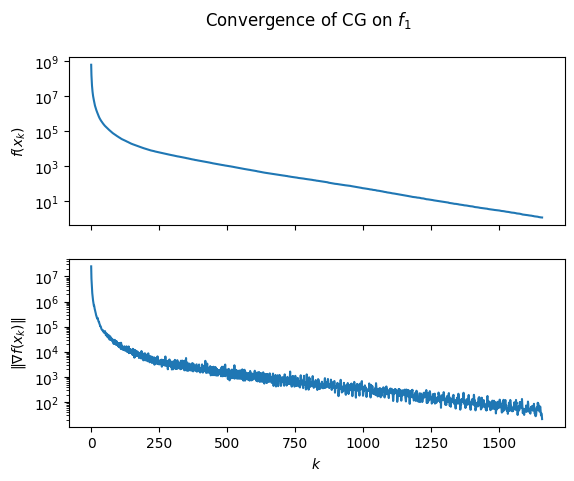

In [3]:
x_star, x_tab = CG_quadratic(pb1.A, pb1.b, pb1.f, pb1.grad_f, np.zeros(pb1.d), 5000, 0.000001)
plot_obj_normGrad(x_tab, pb1.f, pb1.grad_f, r"Convergence of CG on $f_1$")

The algorithm converges to a correct solution.

### Problem 2

In [52]:
import problem2 as pb2

$$f(x) = \sum_{i=0}^{n} \alpha_i^2 \sqrt{1+ (\frac{x-x^*}{\alpha_i})^2}$$
This is a smooth function in high dimensions so the hessian is costly to compute and the condition number is high. Instead of using Newton, we use BFGS, that approximates the Hessian using the gradient of the function stabilizing the computations.

------------------------------------
BFGS algorithm
------------------------------------
START
FINISHED -- 28 iterations -- 0.060948s -- final value: 0.000000 -- final gradient norm: 0.000456 




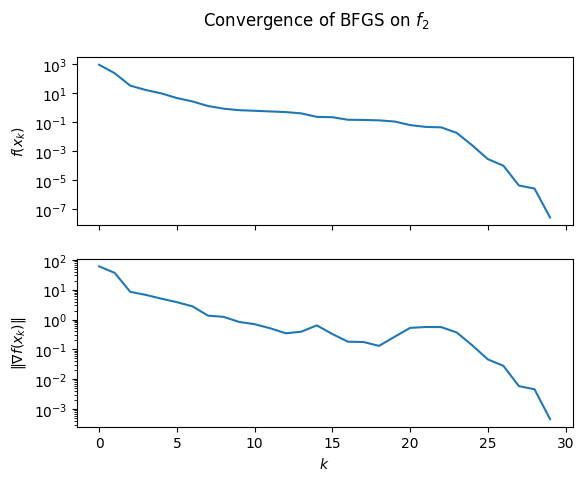

In [56]:
x_init = np.zeros(pb2.d)
#same values as in the other labs
prec = 1e-5
iterMax = 5000

x,x_tab = bfgs(pb2.f , pb2.grad_f , x_init , prec , iterMax )
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of BFGS on $f_2$")

### Problem 3

In [58]:
import problem3 as pb3

This is a two dimensional polynomial of order 6, so the Hessian should be well conditionned and we can use Newton's method.

------------------------------------
Newton's algorithm
------------------------------------
START
FINISHED -- 9 iterations -- 0.000573s -- final value: 0.298639 -- final gradient norm: 0.133797 




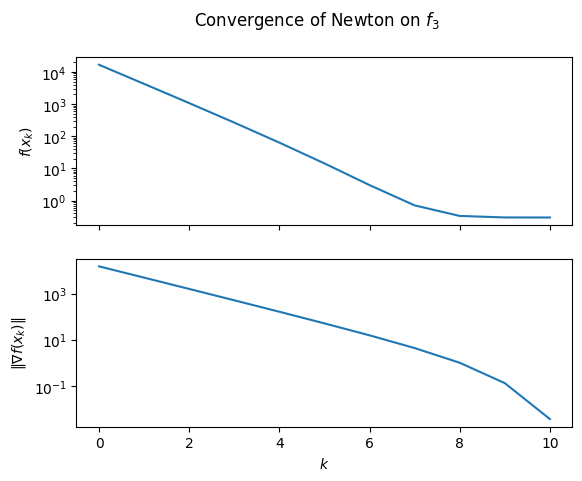

In [59]:
x_init = np.zeros(pb3.d)
prec = 1e-5
iterMax = 5000

x,x_tab = newton(pb3.f , pb3.grad_hessian_f , x_init , prec , iterMax)
plot_obj_normGrad(x_tab, pb3.f, pb3.grad_f, r"Convergence of Newton on $f_3$")

We get fast convergence.

### Problem 4

In [ ]:
import problem4 as pb4

This is a non linear, twice differentiable function, so again we can use Newton's method for fast convergence.

In [73]:
x_init = np.zeros(pb4.d)
prec = 1e-5
iterMax = 5000

x,x_tab = newton_ls(pb4.f , pb4.grad_hessian_f , x_init , prec , iterMax)
plot_obj_normGrad(x_tab, pb4.f, pb4.grad_f, r"Convergence of Newton on $f_4$")

------------------------------------
Newton's algorithm
------------------------------------
START


/home/user/M1AM/Optim/numericalOptimization-M1AM/eval1/algorithms.py:140: LineSearchWarning: The line search algorithm did not converge
  res = line_search(f, lambda x : f_grad_hessian(x)[0], x, dir, gfk=None, old_fval=None, old_old_fval=None, args=(), c1=0.0001, c2=0.9, amax=50)


TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

Newton's method finished but didn't give a good solution as $f(x*) \neq 0$. So we have to try another method. We can use the conjugate gradient for non linear problems.

------------------------------------
 CG for quadratic objective 
------------------------------------
START
FINISHED -- 438 iterations -- 0.033725s -- final value: 0.000000 -- final gradient norm: 0.000000 




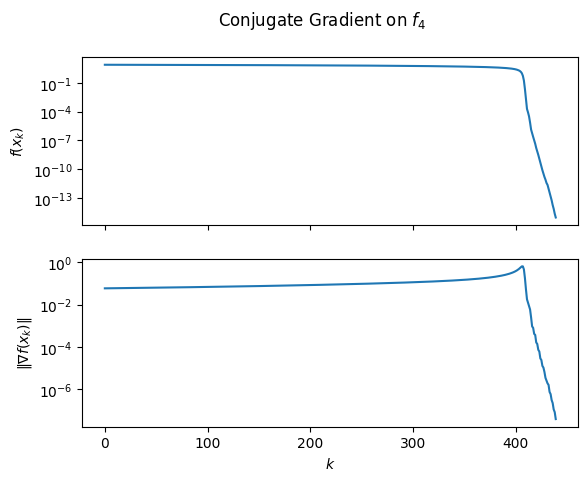

In [65]:
x,x_tab = CG_nonLinear(pb4.f, pb4.grad_f, x_init, 5000, 0.000001, 1.0, 0.5, 0.5)
plot_obj_normGrad(x_tab, pb4.f, pb4.grad_f, r"Conjugate Gradient on $f_4$")

This methods works out.

### Problem 5

In [ ]:
import problem5 as pb5


This is a once differentiable function so we can't use second order methods like Newton. Instead we can use accelerated gradient descent or the conjugate gradient methods.

In [79]:

x_init = np.zeros(pb5.d)
prec = 1e-5
iterMax = 50000
tau = 0.1

x,x_tab = GD_wolfe(pb5.f, pb5.grad_f, x_init, iterMax, prec)

------------------------------------
 Gradient with Wolfe line search
------------------------------------
START


TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
x_init = np.zeros(pb5.d)
prec = 1e-5
iterMax = 5000
tau = 0.1

x, x_tab = GD_accelerated(pb5.f, pb5.grad_f, x_init, tau, iterMax, prec , 0.5)

------------------------------------
 Accelerated GD with constant step size
------------------------------------
START
FINISHED -- 4999 iterations -- 0.572067s -- final value: 90.938635 -- final gradient norm: 54.273537 




In [72]:
x_init = np.zeros(pb5.d)
prec = 1e-5
iterMax = 5000
tau0 = 0.1
rho = 0.5
c = 0.5

CG_nonLinear(pb5.f, pb5.grad_f, x_init, iterMax, prec, tau0, rho, c)

------------------------------------
 CG for quadratic objective 
------------------------------------
START
FINISHED -- 4999 iterations -- 14.099812s -- final value: 65.940050 -- final gradient norm: 24.887673 




(array([ 0.07552148, -5.17627551,  0.91688142, -8.96757186, -9.56394037,
        -5.28282406,  1.36271003, -4.73950675,  7.51316128, -0.33206859,
        -3.35607841, -9.64671542,  6.8517818 , -6.6793213 , -8.63390069,
         0.88550752,  2.59880996, -3.26931743,  0.2718914 ,  2.28471679,
         0.76055908, -8.41749724, -0.49453965, -4.86409191,  3.79134451,
         1.29452561, -4.33118146,  7.55154122,  4.2612796 ,  2.22901184,
        -9.0099999 , -9.92713015,  8.86534499, -6.22326322,  6.26927723,
        -1.51679969,  2.64018774, -6.40232277, -1.90068968,  7.85246099,
        -2.39923012,  5.23952159,  2.79904166,  0.6075895 , -1.22257527,
        -6.70069767,  7.99913177,  2.90665814, -3.51131067, -3.52794362,
        -4.48714678,  7.14987306,  9.5592116 , -3.53937858, -2.11271327,
         6.42517567, -1.05118606, -9.32587291,  5.6162933 ,  4.44337448,
        -0.74102633,  0.36022393,  3.20620869,  9.21012273, -8.30685098,
        -4.13120333, -1.05061331, -7.40816033,  1.6

### Problem 6

In [45]:
import problem6 as pb6

x_init = np.zeros(pb6.d)
prec = 1e-5
iterMax = 5000

Problem 6 is a smooth function with a quadratic term. As the hessian is available and the condition number of the matrix $A$ is not very high, we use Newton's method for fast convergence.

------------------------------------
Newton's algorithm
------------------------------------
START
FINISHED -- 3 iterations -- 0.001233s -- final value: 0.000000 -- final gradient norm: 0.000001 




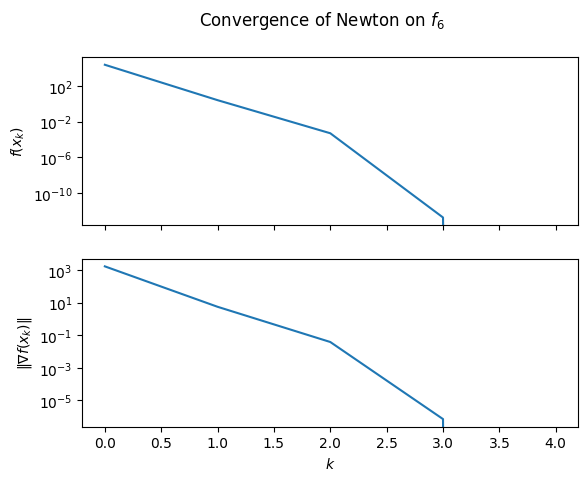

In [63]:
x,x_tab = newton(pb6.f , pb6.grad_hessian_f , x_init , prec , iterMax)
plot_obj_normGrad(x_tab, pb6.f, pb6.grad_f, r"Convergence of Newton on $f_6$")

In this case Newton's method is very effective and we get very fast convergence.